# Chapter 1. 데이터사이언스 파이프라인과 사전지식 리뷰 — 실습 노트북

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/SuminHan/book-ml/blob/main/notebooks/ml1/chapter01_3_pipeline.ipynb)

책 본문: [1.3 데이터사이언스 파이프라인과 사전지식 리뷰](https://smhanlab.com/book-ml/kor/ml1/chapter01.html)

이 노트북은 책 1.3절의 파이프라인(수집 → 정제 → 나누기 → 채움 → 모델링 →
평가)을 끝까지 돌리고, 그 핵심 교훈 — "훈련 점수가 높다"는 사실은 잘
배웠다는 증거가 아니라 **외웠을 가능성**을 알리는 신호일 수 있다는 것 — 을
24차 다항식으로 눈으로 확인합니다. numpy/pandas/matplotlib만 씁니다.

## 0. 설정: 한글 폰트와 import

그래프의 한글 라벨이 깨지지 않도록 CJK 폰트를 골라둡니다 (Colab에 기본 설치).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager

# 그래프의 한글 라벨이 깨지지 않도록 CJK 폰트 사용 (Colab에 기본 설치됨)
for _f in ["Noto Sans CJK KR", "NanumGothic", "Malgun Gothic", "AppleGothic"]:
    if any(_f.lower() == x.name.lower() for x in font_manager.fontManager.ttflist):
        plt.rcParams["font.sans-serif"] = [_f, "DejaVu Sans"]
        break
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["svg.fonttype"] = "path"  # SVG로 내보낼 때 글자를 path로 변환

## 1. EDA: 모델을 돌리기 전에 데이터에 "대화"하기

책의 첫 실습을 그대로 실행합니다. `describe()`(스케일), `corr()`(어떤
특징이 목표와 관련 있는가), `isna().sum()`(결측치) — 이 세 줄이 EDA의
첫 질문들에 답하는 도구입니다.

In [2]:
data = {
    "size_sqm": [59, 84, 112, 46, 132, 78],
    "rooms": [2, 3, 4, 1, 4, 3],
    "year_built": [2015, 2008, 1998, 2020, 1995, 2011],
    "price_million": [320, 410, 505, 250, 560, 390],
}
df = pd.DataFrame(data)

print(df.describe())          # 각 열의 평균/표준편차/최소/최대 한눈에 보기
print(df.corr(numeric_only=True)["price_million"])  # 어떤 특징이 가격과 가장 관련 있는가
print(df.isna().sum())        # 결측치가 열마다 몇 개인지

         size_sqm     rooms   year_built  price_million
count    6.000000  6.000000     6.000000       6.000000
mean    85.166667  2.833333  2007.833333     405.833333
std     32.201967  1.169045     9.703951     114.473432
min     46.000000  1.000000  1995.000000     250.000000
25%     63.750000  2.250000  2000.500000     337.500000
50%     81.000000  3.000000  2009.500000     400.000000
75%    105.000000  3.750000  2014.000000     481.250000
max    132.000000  4.000000  2020.000000     560.000000
size_sqm         0.994999
rooms            0.972666
year_built      -0.992788
price_million    1.000000
Name: price_million, dtype: float64
size_sqm         0
rooms            0
year_built       0
price_million    0
dtype: int64


## 2. 결측치와 그룹별 통계

`dropna()`(행 통째로 버림) vs `fillna()`(중앙값·평균으로 채움).
`groupby()`로 지역별 평균을 보면 "지역 A가 B보다 싼가?" 같은 가설을
모델링 전에 검증할 수 있습니다.

In [3]:
data2 = {
    "size_sqm": [59, 84, 112, 46, 132, 78, np.nan],
    "district": ["A", "B", "A", "C", "B", "A", "C"],
    "price_million": [320, 410, 505, 250, 560, 390, np.nan],
}
df2 = pd.DataFrame(data2)

print(df2.isna().sum())               # size_sqm 1개, price_million 1개 결측
print(len(df2.dropna()))               # 결측 행 제거 후 6행
df2["size_sqm"] = df2["size_sqm"].fillna(df2["size_sqm"].median())  # 중앙값으로 채움
print(df2.groupby("district")["price_million"].mean())  # 지역별 평균가

size_sqm         1
district         0
price_million    1
dtype: int64
6
district
A    405.0
B    485.0
C    250.0
Name: price_million, dtype: float64


## 3. 파이프라인을 처음부터 끝까지

수집(123행, 의도적으로 더티하게) → 정제(중복 제거, 센티넬 -999 발견) →
**나누기** → **채움(훈련 행의 중앙값만 사용)** → 모델링(선형회귀). 책에서
강조한 순서: 통계량이 관여하는 채움은 데이터를 *나눈 뒤*에, *훈련 행만*
으로 중앙값을 계산합니다.

In [4]:
# 1) 수집: 지저분한 데이터셋 시뮬레이션
rng = np.random.default_rng(0)
size = rng.uniform(40, 140, 120)
price = 1.5 * size + 20 + rng.normal(0, 8, 120)

for i in [5, 6, 7]:                                  # 3행 완전 중복
    size = np.append(size, size[i])
    price = np.append(price, price[i])
price[11] = -999.0                                   # 1행 센서 센티넬
df = pd.DataFrame({"size_sqm": size, "price_million": price})

# 2) 정제(행 수준): 중복 제거 — 통계량이 관여하지 않아 나누기 전에 해도 안전
print("rows before cleaning:", len(df))
print("min price:", df["price_million"].min())        # -999가 보인다!
print("duplicate rows:", df.duplicated().sum())
df = df.drop_duplicates().reset_index(drop=True)
print("rows after dedup:", len(df))

# 3) 통계량 기반 정제(채움) *이전*에 데이터를 나눈다
perm = rng.permutation(len(df))
cut = int(0.75 * len(df))
df_tr = df.iloc[perm[:cut]].copy()
df_te = df.iloc[perm[cut:]].copy()
print(f"train {len(df_tr)}, test {len(df_te)}")

# 4) 채움: 훈련 행에서만 중앙값을 계산, 그 통계량을 테스트에 그대로 적용
med = df_tr.loc[df_tr["price_million"] >= 0, "price_million"].median()
print("train median used for imputation:", round(med, 1))
for d in (df_tr, df_te):
    d.loc[d["price_million"] < 0, "price_million"] = med

# 5) 모델링: 선형회귀 y = slope*size + intercept (정상방정식, Chapter 2에서 유도)
def linreg(X, y):
    Xb = np.column_stack([X, np.ones_like(X)])
    w = np.linalg.solve(Xb.T @ Xb, Xb.T @ y)
    return w[0], w[1]

slope, intercept = linreg(df_tr["size_sqm"].values, df_tr["price_million"].values)
print(f"learned slope={slope:.3f}, intercept={intercept:.3f}  (true values: 1.5, 20)")

rows before cleaning: 123
min price: -999.0
duplicate rows: 3
rows after dedup: 120
train 90, test 30
train median used for imputation: 152.6
learned slope=1.400, intercept=29.471  (true values: 1.5, 20)


출력은 책 본문과 똑같아야 합니다: `rows before cleaning: 123`,
`duplicate rows: 3`, `rows after dedup: 120`, `train 90, test 30`,
그리고 학습된 기울기는 진짜 생성 값 1.5에 가까운 `1.400`.

## 4. 평가: R²과 MAE, 그리고 "train과 test가 거의 같은가"

`R²`(결정계수)는 목표 변수 변동 중 모델이 몇 퍼센트를 설명하는지 요약합니다.
중요한 신호는 **train과 test의 R²가 거의 같은가** — 같으면 일반적인 규칙을
배운 것이고, 많이 벌어지면 외운 것입니다.

In [5]:
def r2(y, p):
    return 1 - ((y - p) ** 2).sum() / ((y - y.mean()) ** 2).sum()

def mae(y, p):
    return np.abs(y - p).mean()

Xtr, ytr = df_tr["size_sqm"].values, df_tr["price_million"].values
Xte, yte = df_te["size_sqm"].values, df_te["price_million"].values

print(f"train R2={r2(ytr, slope*Xtr+intercept):.4f}  MAE={mae(ytr, slope*Xtr+intercept):.2f}")
print(f"test  R2={r2(yte, slope*Xte+intercept):.4f}  MAE={mae(yte, slope*Xte+intercept):.2f}")
assert abs(r2(ytr, slope*Xtr+intercept) - 0.9406) < 0.01
assert abs(r2(yte, slope*Xte+intercept) - 0.9561) < 0.01

train R2=0.9406  MAE=7.13
test  R2=0.9561  MAE=7.58


train R²≈0.94, test R²≈0.96 — 거의 같습니다. 선형 모델은 90행을 외운 게
아니라 **일반적인 규칙**을 배운 것입니다.

## 5. 과대적합: "완벽해 보이는" 훈련 점수의 함정

이 절의 핵심 교훈을 가장 극단적으로 보여줍니다. 훈련 행 앞 25행에 24차
다항식을 맞히면 train R²=1.0000(완벽 통과)이 되지만, test R²는 **마이너스
6만** — "평균만 예측하는 모델"(R²=0)보다 몇만 배 나빠집니다.

In [6]:
Xs, ys = Xtr[:25], ytr[:25]
mu, sd = Xs.mean(), Xs.std()          # 표준화 — 스케일 문제(Chapter 4.1)
for deg in [1, 24]:
    V = np.vander((Xs - mu) / sd, N=deg + 1)   # 설계 행렬 [1, x, x^2, ...]
    coef, *_ = np.linalg.lstsq(V, ys, rcond=None)
    Vt = np.vander((Xte - mu) / sd, N=deg + 1)
    print(f"degree {deg}: train R2={r2(ys, V @ coef):.4f}  test R2={r2(yte, Vt @ coef):.4f}")

# 24차: 훈련을 완벽히 통과(≈1.0)하나 테스트는 0(평균만)보다 훨씬 나빠야 한다
V24 = np.vander((Xs - mu) / sd, N=25)
c24, *_ = np.linalg.lstsq(V24, ys, rcond=None)
Vt24 = np.vander((Xte - mu) / sd, N=25)
assert r2(ys, V24 @ c24) > 0.9999, "24차는 25개 훈련 점을 통과해야 함"
assert r2(yte, Vt24 @ c24) < -1000, "테스트는 0(평균만)보다 훨씬 나쁘야 함"
print("assert 통과: 훈련은 1.0000, 테스트는 0보다 훨씬 나쁨 — 과대적합의 정의다.")

degree 1: train R2=0.8820  test R2=0.9368
degree 24: train R2=1.0000  test R2=-63495.2701
assert 통과: 훈련은 1.0000, 테스트는 0보다 훨씬 나쁨 — 과대적합의 정의다.


## 6. 시각화: degree 1 vs degree 24

아래 그림은 책 본문(1.3)에 삽입된 `ch01_overfitting.svg`를 만든 것입니다.
왼쪽(degree 1)은 점들의 *경향*을 따라가고, 오른쪽(24차)은 25개 훈련 점에
붙어 **점과 점 사이의 잡음 자체**를 외운 곡선입니다 — 그래서 훈련 밖(빨간
삼각, 테스트)에서는 광범위하게 흔들립니다.

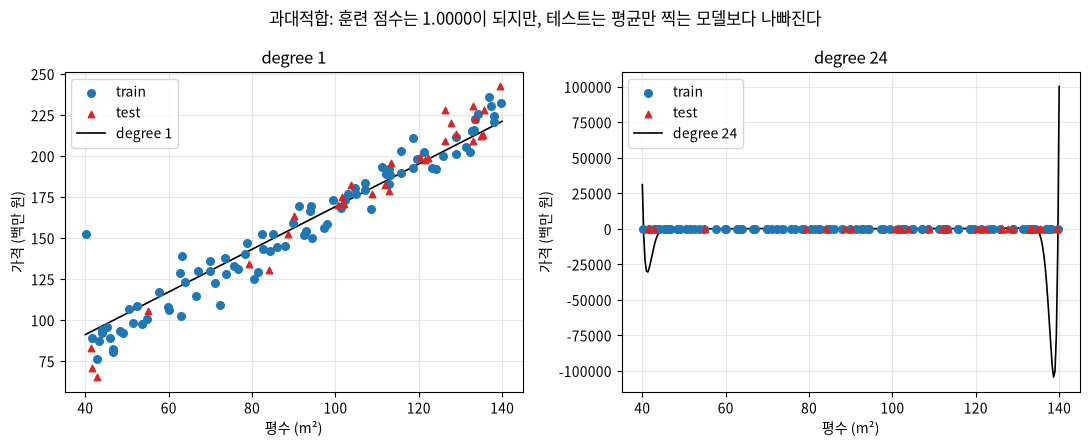

ch01_overfitting.svg 저장됨


In [7]:
xs = np.linspace(40, 140, 300)
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for deg, ax in zip([1, 24], axes):
    V = np.vander((Xs - mu) / sd, N=deg + 1)
    coef, *_ = np.linalg.lstsq(V, ys, rcond=None)
    ax.scatter(Xtr, ytr, c="tab:blue", s=30, label="train", zorder=3)
    ax.scatter(Xte, yte, c="tab:red", s=22, marker="^", label="test", zorder=3)
    ax.plot(xs, coef @ np.vander((xs - mu) / sd, N=deg + 1).T, "k-", lw=1.2, label=f"degree {deg}")
    ax.set_title(f"degree {deg}")
    ax.set_xlabel("평수 (m²)")
    ax.set_ylabel("가격 (백만 원)")
    ax.legend()
    ax.grid(alpha=0.3)
plt.suptitle("과대적합: 훈련 점수는 1.0000이 되지만, 테스트는 평균만 찍는 모델보다 나빠진다")
plt.tight_layout()
plt.show()

# 본문에 삽입할 SVG로 저장 (글자는 path로 변환해 어떤 뷰어에서도 동일하게 표시)
fig.savefig("ch01_overfitting.svg")  # fonttype는 cell 0에서 rcParams로 'path'로 설정
print("ch01_overfitting.svg 저장됨")

## 7. 수학과 Python 사전지식 리뷰: 내적과 행렬곱

이번 학기 거의 모든 챕터의 첫 줄에 등장하는 \(w^Tx\)를 numpy 한 줄로
보입니다. `X @ w`(행렬-벡터 곱)가 그 표현입니다.

In [8]:
X = np.array([[1.0, 2.0], [3.0, 4.0]])  # 2x2 행렬
w = np.array([0.5, -0.5])               # 길이 2 벡터
res = X @ w   # 행렬-벡터 곱: [-0.5, -0.5]
print(res)
assert np.allclose(res, [-0.5, -0.5])

# 손으로 푼 내적: w=[2,-1,3], x=[1,4,2] -> 4
w2, x2 = [2, -1, 3], [1, 4, 2]
dot = sum(a * b for a, b in zip(w2, x2))
print(f"w·x = {dot}")
assert dot == 4
print("모두 일치! 이 한 줄(w·x)이 이번 학기 거의 모든 챕터의 첫 줄이다.")

[-0.5 -0.5]
w·x = 4
모두 일치! 이 한 줄(w·x)이 이번 학기 거의 모든 챕터의 첫 줄이다.
